# SmolVLA XAI At Dataset Episode 0, Around 13s

Notebook này lấy frame gần `t = 13s` của `episode_index = 0` từ dataset `di-techinnova/so-arm-101-pouring-0.3-cutted`, export thành một thư mục `recorded_obs` mini, rồi chạy heatmap SmolVLA.

Hai loại heatmap:

1. **Occlusion sensitivity**: khuyến nghị. Đây là causal test: che từng vùng ảnh, đo action thay đổi bao nhiêu. Script đã được chỉnh để dùng `metadata.jsonl` state thật.
2. **Raw attention**: chỉ để tham khảo. README đã cảnh báo SmolVLA raw attention thường bị attention-sink/saliency dominate, không nên coi là word grounding chắc chắn.


In [1]:
from __future__ import annotations

import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

from lerobot.datasets.lerobot_dataset import LeRobotDataset

REPO_ROOT = Path.cwd()
DATASET_REPO = 'di-techinnova/so-arm-101-pouring-0.3-cutted'
DATASET_ROOT = Path('/home/trietlm/lerobot/data/so-arm-101-pouring-0.3-cutted')

EPISODE_INDEX = 0
TARGET_SECONDS = 13.0
MODEL = 'di-techinnova/smolvla-pouring-0.3-cutted'
INSTRUCTION = 'Pour from orange cup to blue cup.'
OUT_DIR = REPO_ROOT / 'xai' / 'dataset_ep0_13s_recorded_obs'

JOINT_KEYS = [
    'shoulder_pan.pos',
    'shoulder_lift.pos',
    'elbow_flex.pos',
    'wrist_flex.pos',
    'wrist_roll.pos',
    'gripper.pos',
]

print('repo root:', REPO_ROOT)
print('dataset root:', DATASET_ROOT)


/home/trietlm/lerobot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo root: /home/trietlm/lerobot/xai
dataset root: /home/trietlm/lerobot/data/so-arm-101-pouring-0.3-cutted


In [2]:
ds = LeRobotDataset(DATASET_REPO, root=DATASET_ROOT, video_backend='pyav')
fps = int(ds.fps)
target_frame = int(round(TARGET_SECONDS * fps))
print(ds)
print('fps:', fps, '| target_frame:', target_frame)


LeRobotDataset({
    Repository ID: 'di-techinnova/so-arm-101-pouring-0.3-cutted',
    Number of selected episodes: '175',
    Number of selected samples: '73803',
    Features: '['action', 'observation.state', 'observation.images.camera1', 'observation.images.camera2', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})
fps: 15 | target_frame: 195


In [3]:
data_files = sorted((Path(ds.root) / 'data').glob('**/*.parquet'))
df = pd.concat(
    [pd.read_parquet(p, columns=['index', 'episode_index', 'frame_index', 'timestamp', 'observation.state', 'action']) for p in data_files],
    ignore_index=True,
)
ep = df[df['episode_index'] == EPISODE_INDEX].copy().sort_values('frame_index')
if ep.empty:
    raise RuntimeError(f'No episode {EPISODE_INDEX}')
row = ep.iloc[(ep['timestamp'] - TARGET_SECONDS).abs().argmin()]
global_index = int(row['index'])
frame_index = int(row['frame_index'])
timestamp = float(row['timestamp'])
print('selected global_index:', global_index)
print('episode/frame/timestamp:', int(row['episode_index']), frame_index, timestamp)
print('state:', np.asarray(row['observation.state']).round(3).tolist())
print('action:', np.asarray(row['action']).round(3).tolist())


selected global_index: 195
episode/frame/timestamp: 0 195 13.0
state: [-8.879, 34.418, -11.077, -30.198, 35.648, 3.21]
action: [-9.407, 33.011, -17.538, -30.286, 40.835, 1.047]


In [4]:
def to_hwc_uint8(x):
    if hasattr(x, 'detach'):
        x = x.detach().cpu().numpy()
    arr = np.asarray(x)
    if arr.ndim != 3:
        raise ValueError(arr.shape)
    if arr.shape[0] in (1, 3):
        arr = np.transpose(arr, (1, 2, 0))
    if arr.dtype != np.uint8:
        if arr.max() <= 1.0:
            arr = arr * 255.0
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return arr

item = ds[global_index]
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
(OUT_DIR / 'images' / 'camera1').mkdir(parents=True)
(OUT_DIR / 'images' / 'camera2').mkdir(parents=True)

for cam in ['camera1', 'camera2']:
    key = f'observation.images.{cam}'
    img = to_hwc_uint8(item[key])
    Image.fromarray(img).save(OUT_DIR / 'images' / cam / f'{frame_index:06d}.png')

state = np.asarray(row['observation.state'], dtype=float)
meta = {
    'timestep': frame_index,
    'elapsed_s': timestamp,
    'abs_timestamp': timestamp,
    'cameras': ['camera1', 'camera2'],
    'state': {k: float(v) for k, v in zip(JOINT_KEYS, state, strict=False)},
    'dataset_repo': DATASET_REPO,
    'episode_index': EPISODE_INDEX,
    'frame_index': frame_index,
    'global_index': global_index,
}
(OUT_DIR / 'metadata.jsonl').write_text(json.dumps(meta) + '\n', encoding='utf-8')

print('wrote', OUT_DIR)
print('files:', list(OUT_DIR.glob('**/*'))[:10])


wrote /home/trietlm/lerobot/xai/xai/dataset_ep0_13s_recorded_obs
files: [PosixPath('/home/trietlm/lerobot/xai/xai/dataset_ep0_13s_recorded_obs/images'), PosixPath('/home/trietlm/lerobot/xai/xai/dataset_ep0_13s_recorded_obs/metadata.jsonl'), PosixPath('/home/trietlm/lerobot/xai/xai/dataset_ep0_13s_recorded_obs/images/camera1'), PosixPath('/home/trietlm/lerobot/xai/xai/dataset_ep0_13s_recorded_obs/images/camera2'), PosixPath('/home/trietlm/lerobot/xai/xai/dataset_ep0_13s_recorded_obs/images/camera1/000195.png'), PosixPath('/home/trietlm/lerobot/xai/xai/dataset_ep0_13s_recorded_obs/images/camera2/000195.png')]


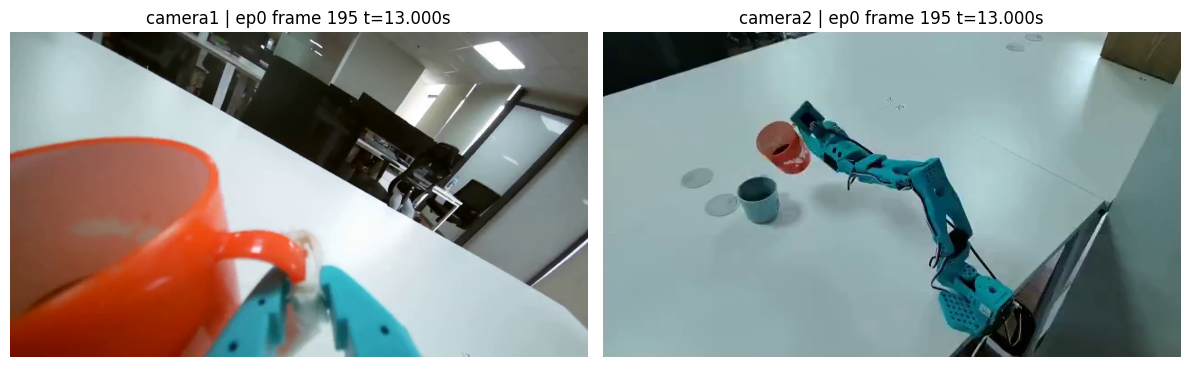

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cam in zip(axes, ['camera1', 'camera2']):
    img = Image.open(OUT_DIR / 'images' / cam / f'{frame_index:06d}.png')
    ax.imshow(img)
    ax.set_title(f'{cam} | ep{EPISODE_INDEX} frame {frame_index} t={timestamp:.3f}s')
    ax.axis('off')
plt.tight_layout()
plt.show()


## Run Causal Occlusion Heatmap

Run from repo root on the GPU server. `--frames 0` means the first file in the mini obs directory; the filename remains the true dataset frame index, and the script uses `metadata.jsonl` state for that timestep.


In [6]:
cmd_occ = f'''
uv run python xai/attention/xai_smolvla_occlusion.py \\
  --device cuda \\
  --obs-dir {OUT_DIR} \\
  --model {MODEL} \\
  --instruction "{INSTRUCTION}" \\
  --frames 0 \\
  --cameras camera1 camera2 \\
  --grid 8 \\
  --use-metadata-state
'''.strip()
print(cmd_occ)


uv run python xai/attention/xai_smolvla_occlusion.py \
  --device cuda \
  --obs-dir /home/trietlm/lerobot/xai/xai/dataset_ep0_13s_recorded_obs \
  --model di-techinnova/smolvla-pouring-0.3-cutted \
  --instruction "Pour from orange cup to blue cup." \
  --frames 0 \
  --cameras camera1 camera2 \
  --grid 8 \
  --use-metadata-state


Optional word-contrast examples. These are slower because they compare full instruction vs word-ablated instruction per occlusion cell.


In [7]:
for word in ['orange', 'blue', 'cup']:
    print(f'''
uv run python xai/attention/xai_smolvla_occlusion.py \\
  --device cuda \\
  --obs-dir {OUT_DIR} \\
  --model {MODEL} \\
  --instruction "{INSTRUCTION}" \\
  --frames 0 \\
  --cameras camera1 camera2 \\
  --grid 6 \\
  --word {word} \\
  --use-metadata-state
'''.strip(), '\n')


uv run python xai/attention/xai_smolvla_occlusion.py \
  --device cuda \
  --obs-dir /home/trietlm/lerobot/xai/xai/dataset_ep0_13s_recorded_obs \
  --model di-techinnova/smolvla-pouring-0.3-cutted \
  --instruction "Pour from orange cup to blue cup." \
  --frames 0 \
  --cameras camera1 camera2 \
  --grid 6 \
  --word orange \
  --use-metadata-state 

uv run python xai/attention/xai_smolvla_occlusion.py \
  --device cuda \
  --obs-dir /home/trietlm/lerobot/xai/xai/dataset_ep0_13s_recorded_obs \
  --model di-techinnova/smolvla-pouring-0.3-cutted \
  --instruction "Pour from orange cup to blue cup." \
  --frames 0 \
  --cameras camera1 camera2 \
  --grid 6 \
  --word blue \
  --use-metadata-state 

uv run python xai/attention/xai_smolvla_occlusion.py \
  --device cuda \
  --obs-dir /home/trietlm/lerobot/xai/xai/dataset_ep0_13s_recorded_obs \
  --model di-techinnova/smolvla-pouring-0.3-cutted \
  --instruction "Pour from orange cup to blue cup." \
  --frames 0 \
  --cameras camera1 camera

## Optional Raw Attention Video/Figure

This is less causal than occlusion. Since the mini folder has one frame, it will create a very short MP4, one per camera.


In [8]:
cmd_attn = f'''
uv run python xai/attention/xai_smolvla_attention_video.py \\
  --obs-dir {OUT_DIR} \\
  --model {MODEL} \\
  --instruction "{INSTRUCTION}" \\
  --fps 1 \\
  --topk 6 \\
  --max-words 8 \\
  --max-frames 1 \\
  --device cuda
'''.strip()
print(cmd_attn)


uv run python xai/attention/xai_smolvla_attention_video.py \
  --obs-dir /home/trietlm/lerobot/xai/xai/dataset_ep0_13s_recorded_obs \
  --model di-techinnova/smolvla-pouring-0.3-cutted \
  --instruction "Pour from orange cup to blue cup." \
  --fps 1 \
  --topk 6 \
  --max-words 8 \
  --max-frames 1 \
  --device cuda
